In [1]:
from astropy import table

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    plot_raw_phase_folded_lightcurve,
    attach_flux_mean_magnitudes,
    attach_periodogram_periods,
    plot_lomb_scargle_periodogram,
    plot_period_mean_g,
    plot_vari_rrlyrae_period_comparison,
    plot_fourier_harmonic_fits,
    cross_validate_harmonics,
)


Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
query = """
SELECT TOP 100 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND num_clean_epochs_g > 40
ORDER BY num_clean_epochs_g DESC
"""


In [3]:
rrlyrae = GaiaData(query, include_lightcurve=True)

rrlyrae.data[:10]


solution_id,source_id,pf,pf_error,p1_o,p1_o_error,epoch_g,epoch_g_error,epoch_bp,epoch_bp_error,epoch_rp,epoch_rp_error,epoch_rv,epoch_rv_error,int_average_g,int_average_g_error,int_average_bp,int_average_bp_error,int_average_rp,int_average_rp_error,average_rv,average_rv_error,peak_to_peak_g,peak_to_peak_g_error,peak_to_peak_bp,peak_to_peak_bp_error,peak_to_peak_rp,peak_to_peak_rp_error,peak_to_peak_rv,peak_to_peak_rv_error,metallicity,metallicity_error,r21_g,r21_g_error,r31_g,r31_g_error,phi21_g,phi21_g_error,phi31_g,phi31_g_error,num_clean_epochs_g,num_clean_epochs_bp,num_clean_epochs_rp,num_clean_epochs_rv,zp_mag_g,zp_mag_bp,zp_mag_rp,num_harmonics_for_p1_g,num_harmonics_for_p1_bp,num_harmonics_for_p1_rp,num_harmonics_for_p1_rv,reference_time_g,reference_time_bp,reference_time_rp,reference_time_rv,fund_freq1,fund_freq1_error,fund_freq2,fund_freq2_error,fund_freq1_harmonic_ampl_g,fund_freq1_harmonic_ampl_g_error,fund_freq1_harmonic_phase_g,fund_freq1_harmonic_phase_g_error,fund_freq1_harmonic_ampl_bp,fund_freq1_harmonic_ampl_bp_error,fund_freq1_harmonic_phase_bp,fund_freq1_harmonic_phase_bp_error,fund_freq1_harmonic_ampl_rp,fund_freq1_harmonic_ampl_rp_error,fund_freq1_harmonic_phase_rp,fund_freq1_harmonic_phase_rp_error,fund_freq1_harmonic_ampl_rv,fund_freq1_harmonic_ampl_rv_error,fund_freq1_harmonic_phase_rv,fund_freq1_harmonic_phase_rv_error,best_classification,g_absorption,g_absorption_error
,,d,d,d,d,d,d,d,d,d,d,d,d,mag,mag,mag,mag,mag,mag,km / s,km / s,mag,mag,mag,mag,mag,mag,km / s,km / s,dex,dex,,,,,rad,rad,rad,rad,,,,,mag,mag,mag,,,,,d,d,d,d,1 / d,1 / d,1 / d,1 / d,mag,mag,rad,rad,mag,mag,rad,rad,mag,mag,rad,rad,km / s,km / s,rad,rad,,mag,mag
int64,int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,int16,int16,int16,int16,float64,float64,float64,float64,float64,float32,float64,float32,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float32,float32
375316653866487565,5284173207165634048,0.6754204135600004,1.14527e-05,--,--,1664.7147255940913,1.6196564e-05,1664.725090176758,4.3462893e-05,1664.7448980260845,5.088851e-05,--,--,19.021461,0.0015568832,19.218428,0.0108482,18.57285,0.007794851,--,--,0.23490465,0.005222299,0.25476402,0.03279039,0.19802193,0.020892723,--,--,-0.9399567,0.39976972,0.3227774,0.021646043,0.1224213,0.021695046,4.2703824,0.08953599,2.5574005,0.23331897,257,246,242,--,19.02329,19.22096,18.573446,3,2,2,--,1666.4768974530693,1666.4772118301444,1666.4773006462092,--,1.4805593374491128,2.5104959e-05,--,--,[0.10287211835384369 0.03320479393005371 0.012593737803399563 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.002026671776548028 0.002223402028903365 0.002232055412605405 -- -- --\n -- -- -- -- -- -- -- -- -- --],[0.21112152934074402 4.692625045776367 3.190765142440796 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0],[0.027860915288329124 0.06460897624492645 0.2089683562517166 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.11212261021137238 0.046277161687612534 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.018480001017451286 0.02448887564241886 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.45994314551353455 4.471524715423584 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.16694127023220062 0.6190136075019836 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.06839297711849213 0.04667317494750023 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.011212748475372791 0.009829183109104633 -- -- -- -- -- -- -- -- -- --\n -- -- -- --],[6.272590160369873 4.2616424560546875 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.17579962313175201 0.2635345757007599 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[],[],[],[],

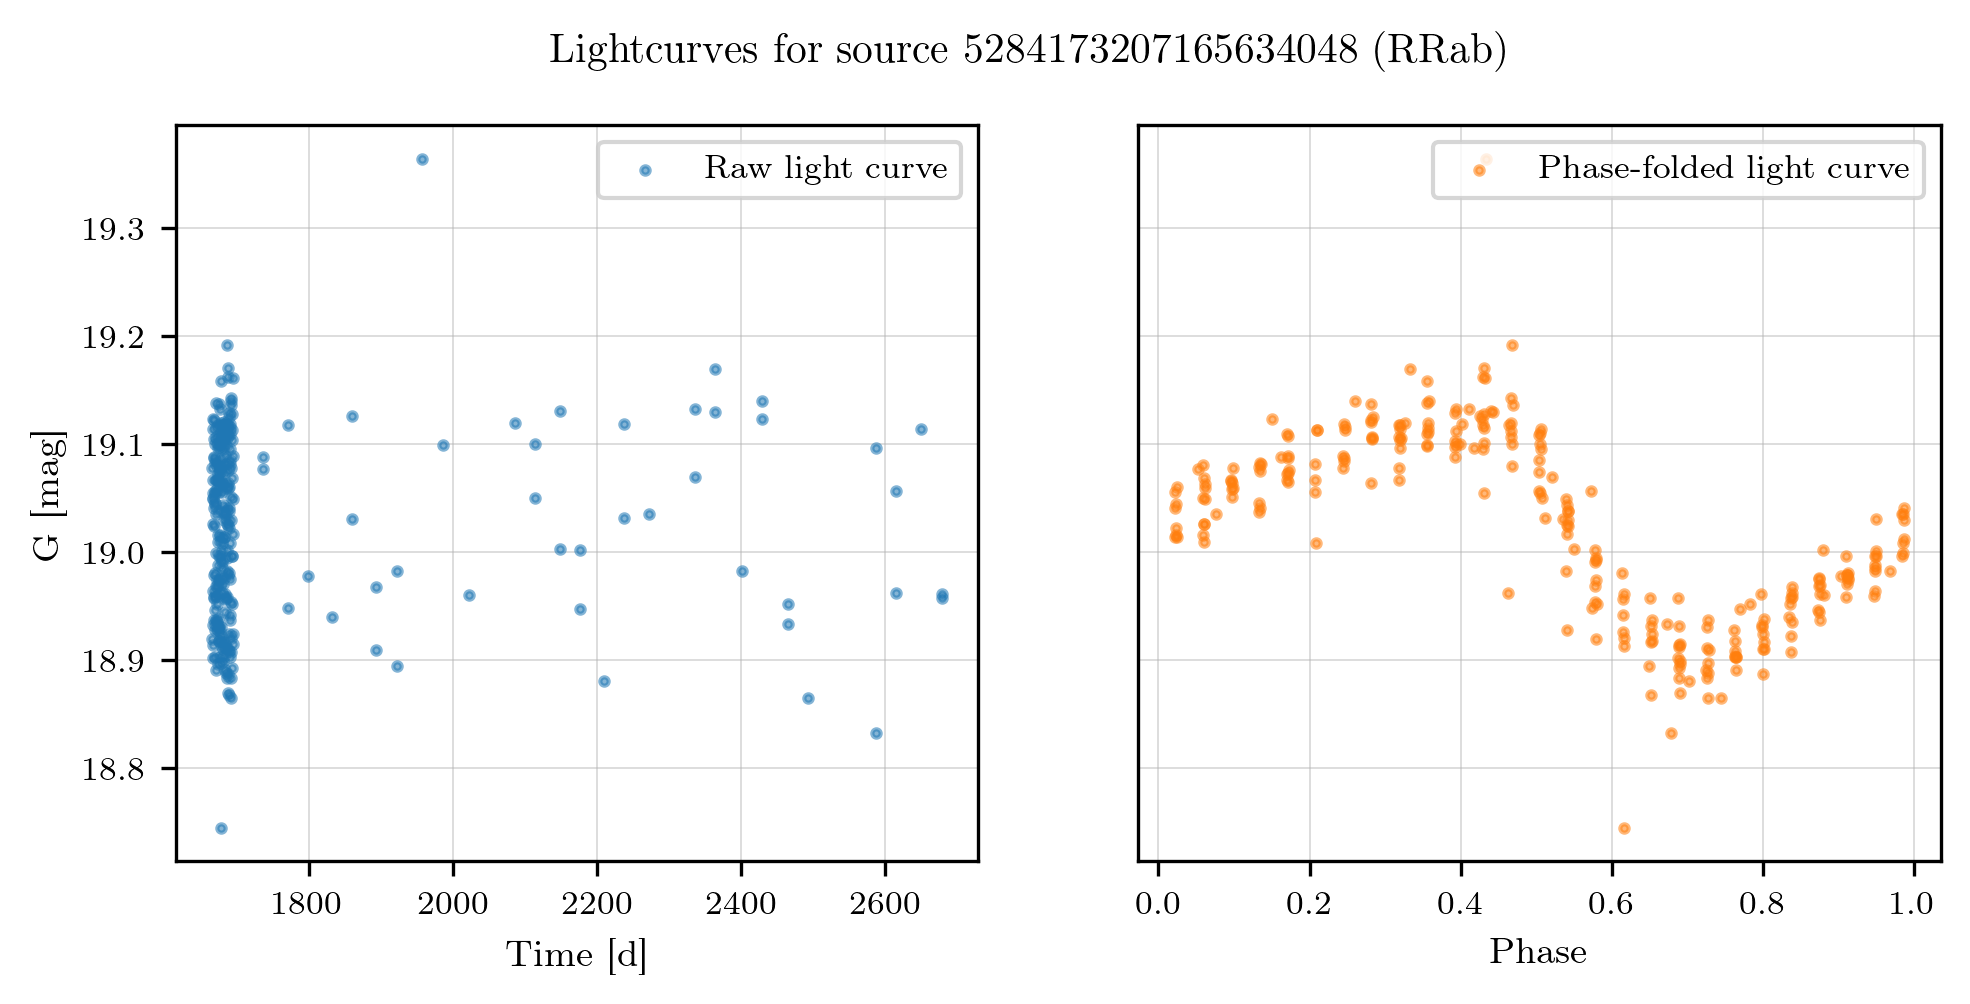

In [4]:
first_star = rrlyrae.data[0]
source_id = int(first_star["source_id"])
best_classification = str(first_star["best_classification"])
adopted_period = float(first_star["pf"])

first_lightcurve = rrlyrae.lightcurve_data[
    np.asarray(rrlyrae.lightcurve_data["source_id"], dtype=np.int64) == source_id
]

axes = plot_raw_phase_folded_lightcurve(first_lightcurve, best_classification, adopted_period)
plt.show()

In [5]:
lightcurve_data = attach_periodogram_periods(attach_flux_mean_magnitudes(rrlyrae.lightcurve_data))

source_id_values = np.asarray(lightcurve_data["source_id"], dtype=np.int64)
source_ids, first_idx, counts = np.unique(source_id_values, return_index=True, return_counts=True)
summary_rows = lightcurve_data[np.asarray(first_idx, dtype=int)]

summary = table.Table(
    {
        "source_id": np.asarray(source_ids, dtype=np.int64),
        "best_classification": summary_rows["best_classification"],
        "n_epochs": np.asarray(counts, dtype=int),
        "pf": np.asarray(np.ma.filled(summary_rows["pf"], np.nan), dtype=float),
        "pf_error": np.asarray(np.ma.filled(summary_rows["pf_error"], np.nan), dtype=float),
        "p1_o": np.asarray(np.ma.filled(summary_rows["p1_o"], np.nan), dtype=float),
        "p1_o_error": np.asarray(np.ma.filled(summary_rows["p1_o_error"], np.nan), dtype=float),
        "best_period": np.asarray(summary_rows["period_ls"], dtype=float),
        "mean_apparent_g": np.asarray(summary_rows["mean_g_transit_mag"], dtype=float),
        "mean_apparent_g_err": np.asarray(summary_rows["mean_g_transit_mag_err"], dtype=float),
    }
)

summary[
    "source_id",
    "best_classification",
    "n_epochs",
    "pf",
    "p1_o",
    "best_period",
    "mean_apparent_g",
    "mean_apparent_g_err",
][:10]


source_id,best_classification,n_epochs,pf,p1_o,best_period,mean_apparent_g,mean_apparent_g_err
int64,object,int64,float64,float64,float64,float64,float64
2161723289949628288,RRab,254,0.52120744664845,nan,0.5211808286461959,18.012706411438742,0.003122876604886266
4659671699480524672,RRab,250,0.5727057170646728,nan,0.572702616543498,19.03500324830371,0.0041710843987278505
4659671768199981824,RRd,247,0.5105986492527866,0.3808748574875205,0.38087821986401127,18.98922312099697,0.014172054749079064
4659672936432993408,RRab,258,0.5565264350513908,nan,0.5565438793427747,19.20513384670247,0.004409149871041425
4659675509114516224,RRd,248,0.4718617187502126,0.3508347485188077,0.3508415070658297,19.28913005581656,0.003783440294753638
4659692830708745472,RRd,259,0.49809852140300886,0.3707070836042074,0.37071438279554514,18.974257588073677,0.003940670502140079
4659694067664043648,RRab,254,0.5121978022026014,nan,0.5121839872734384,18.785753745251437,0.003289787097450397
4659694239447681792,RRab,253,0.5828427671637346,nan,0.5828626801775547,19.36131846177173,0.004119463702611087
4659703069916687872,RRab,246,0.5584606987263409,nan,0.5584620963988325,19.038591451716268,0.004577405316774536


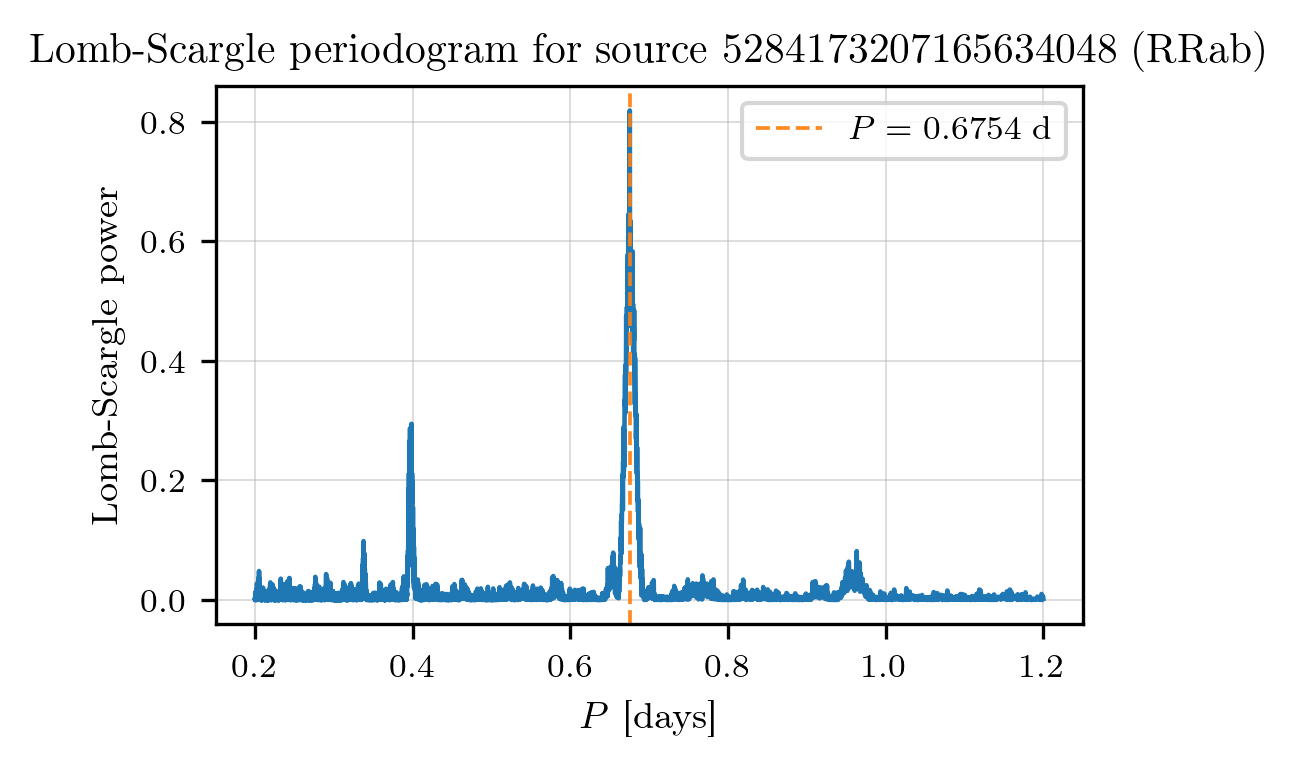

In [6]:
target = lightcurve_data[np.asarray(lightcurve_data["source_id"], dtype=np.int64) == source_id]
best_classification = str(target[0]["best_classification"])

ax = plot_lomb_scargle_periodogram(target, best_classification)
plt.show()

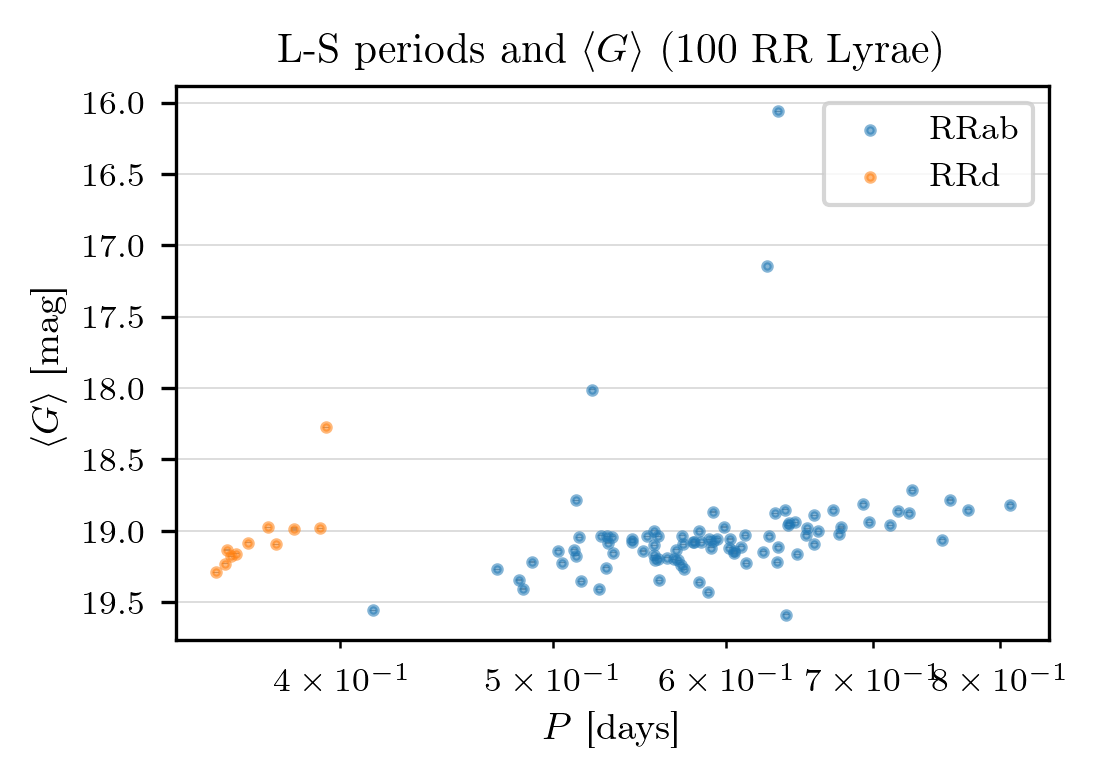

In [7]:
classifications = np.asarray(summary["best_classification"]).astype(str)

ax = plot_period_mean_g(summary, classifications)
plt.show()

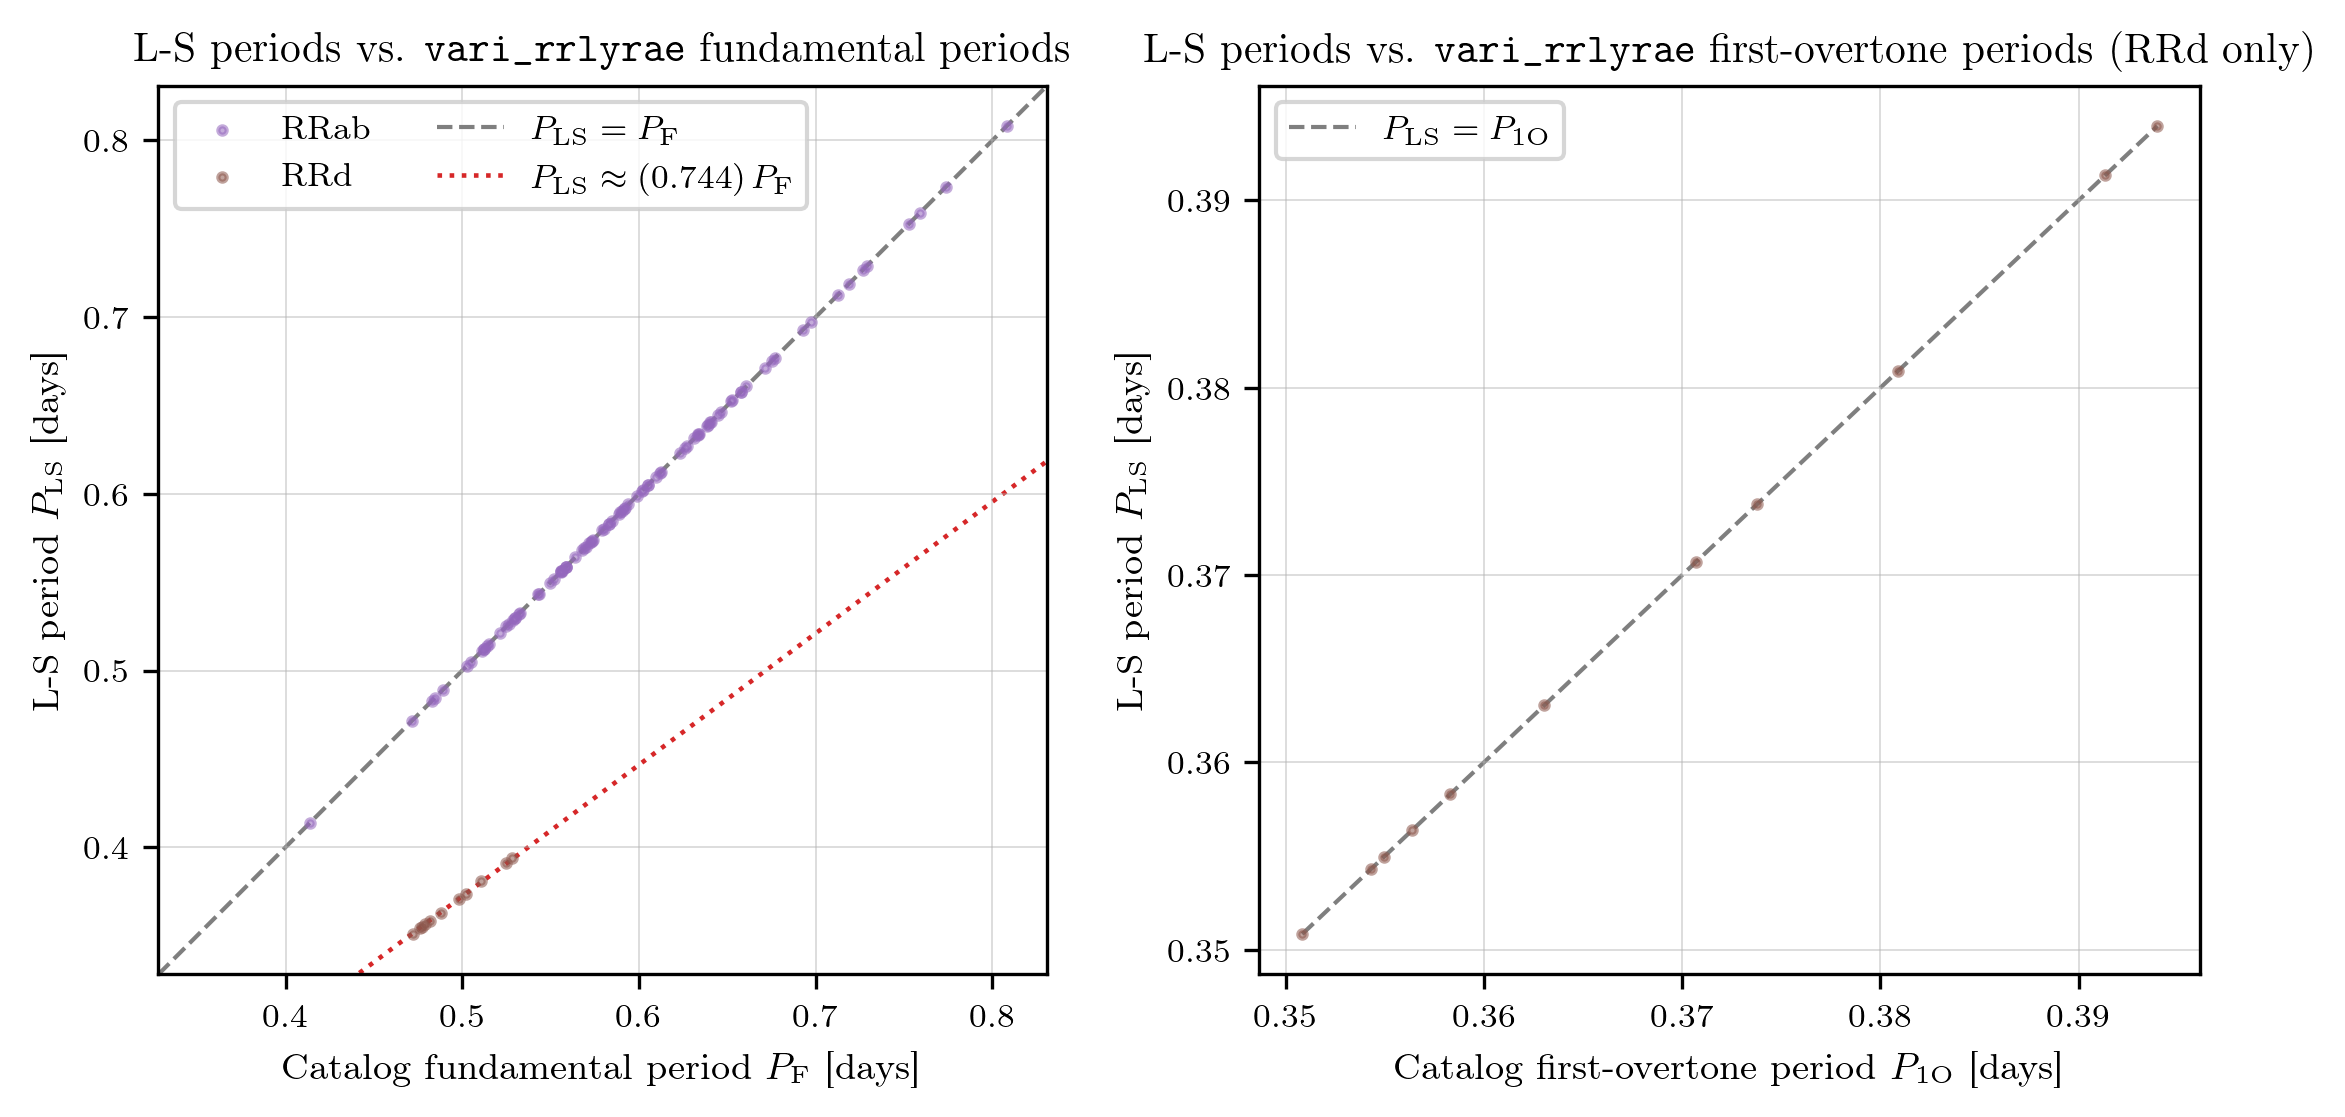

In [8]:
classifications = np.asarray(summary["best_classification"]).astype(str)

axes = plot_vari_rrlyrae_period_comparison(summary, classifications)
plt.show()

## Analysis and Discussion

The two-panel comparison makes the period recovery easier to interpret. In the **left panel**, the Lomb-Scargle periods are compared to the `vari_rrlyrae` **fundamental periods** `pf`, so this is the appropriate comparison for the RRab stars and a first-pass comparison for the RRd stars. Most stars lie very close to the 1:1 relation: for these 100 light curves, the median absolute period difference is **0.0000 d**, the median absolute fractional difference is **0.00\%**, and **89/100** stars agree to better than **1\%**. This indicates that the Lomb-Scargle analysis recovers the Gaia catalog period well for the large majority of the sample, consistent with the high quality of the Gaia DR3 RR Lyrae classifications and periods for single-mode stars (Clementini et al. 2023).

The remaining mismatches are not randomly scattered across the sample. The largest discrepancy is for source **4659675509114516224**, where $P_{\rm F} = 0.4719\,\mathrm{d}$ but $P_{\rm LS} = 0.3508\,\mathrm{d}$. These outliers are concentrated in the **RRd** subclass. That behavior is physically expected because RRd stars are **double-mode RR Lyrae**: they pulsate simultaneously in the **fundamental** and **first-overtone** radial modes, and Gaia DR3 reports those two periods separately as `pf` and `p1_o` in the `vari_rrlyrae` table (Gaia DR3 `vari_rrlyrae` metadata; Clementini et al. 2023).

That is why the **right panel** is important. It compares the Lomb-Scargle periods only for RRd stars against the Gaia **first-overtone** period `p1_o`. In this comparison, the RRd stars move much closer to the 1:1 relation. Quantitatively, the median catalog ratio is $P_{1\rm O}/P_{\rm F} = 0.744$, which is fully consistent with the classical RRd period-ratio range $P_1/P_0 \approx 0.74$--$0.75$ and with the narrow Petersen-diagram sequence followed by most RRd stars (Nemec & Moskalik 2024). The median ratio $P_{1\rm O}/P_{\rm LS} = 1.000$ further shows that the single-period Lomb-Scargle estimate is typically locking onto the **first-overtone** mode rather than the fundamental mode.

So the apparent disagreement in the left panel does **not** mainly indicate failed period recovery. Instead, it reflects a **mode-identification issue**: a one-frequency Lomb-Scargle periodogram returns the strongest single periodicity in the light curve, whereas an RRd star truly contains two astrophysical periods. For RRab stars, that ambiguity does not arise and the agreement with `pf` is excellent. For RRd stars, the fundamental-period comparison is still useful because it flags the objects that are multi-periodic, but the physically more informative comparison is the first-overtone panel. This interpretation is also consistent with the fact that, in classical RRd stars, the first overtone often has the larger observed amplitude and can therefore dominate a single-frequency period search (Nemec & Moskalik 2024).

### References
- G. Clementini et al. (2023), *Gaia Data Release 3 - Specific processing and validation of all-sky RR Lyrae and Cepheid stars: The RR Lyrae sample*, A&A 674, A18. https://www.aanda.org/articles/aa/full_html/2023/06/aa43964-22/aa43964-22.html
- Gaia DR3 `vari_rrlyrae` table metadata, including the definitions of `pf`, `pf_error`, `p1_o`, and `p1_o_error`. https://gaia.aip.de/metadata/gaiadr3/vari_rrlyrae/
- J. M. Nemec & P. Moskalik (2024), *Double-mode RR Lyrae stars observed by K2: analysis of high-precision Kepler photometry*, MNRAS 529, 296. https://academic.oup.com/mnras/article/529/1/296/7606327


## Fourier Model as Linear Algebra

If the angular frequency $\omega = 2\pi/P$ is known, then the Fourier model is **linear** in the remaining coefficients. Writing the model at an observation time $t_i$ gives

$$
y_i = A_0 + \sum_{k=1}^K \left[a_k \sin(k\omega t_i) + b_k \cos(k\omega t_i)\right],
$$

where $y_i$ is the measured flux (or magnitude) at time $t_i$. We can rewrite this as a dot product,

$$
y_i = \mathbf{x}_i^\top \boldsymbol{\beta},
$$

with

$$
\mathbf{x}_i = \begin{bmatrix}
1,
\cos(\omega t_i),
\sin(\omega t_i),
\cos(2\omega t_i),
\sin(2\omega t_i),
\ldots,
\cos(K\omega t_i),
\sin(K\omega t_i)
\end{bmatrix},
\qquad
\boldsymbol{\beta} = \begin{bmatrix}
A_0,
b_1,
a_1,
b_2,
a_2,
\ldots,
b_K,
a_K
\end{bmatrix}.
$$

Stacking all $N$ observations together gives the matrix equation

$$
\mathbf{y} = X\boldsymbol{\beta},
$$

where

$$
\mathbf{y} = \begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{bmatrix},
$$

and the design matrix $X$ has one row per observation time:

$$
X = \begin{bmatrix}
1 & \cos(\omega t_1) & \sin(\omega t_1) & \cos(2\omega t_1) & \sin(2\omega t_1) & \cdots & \cos(K\omega t_1) & \sin(K\omega t_1) \\
1 & \cos(\omega t_2) & \sin(\omega t_2) & \cos(2\omega t_2) & \sin(2\omega t_2) & \cdots & \cos(K\omega t_2) & \sin(K\omega t_2) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
1 & \cos(\omega t_N) & \sin(\omega t_N) & \cos(2\omega t_N) & \sin(2\omega t_N) & \cdots & \cos(K\omega t_N) & \sin(K\omega t_N)
\end{bmatrix}.
$$

So once $\omega$ is fixed, fitting the Fourier series reduces to solving for the coefficient vector $\boldsymbol{\beta}$ in a linear model. In practice, this is done with ordinary or weighted least squares.


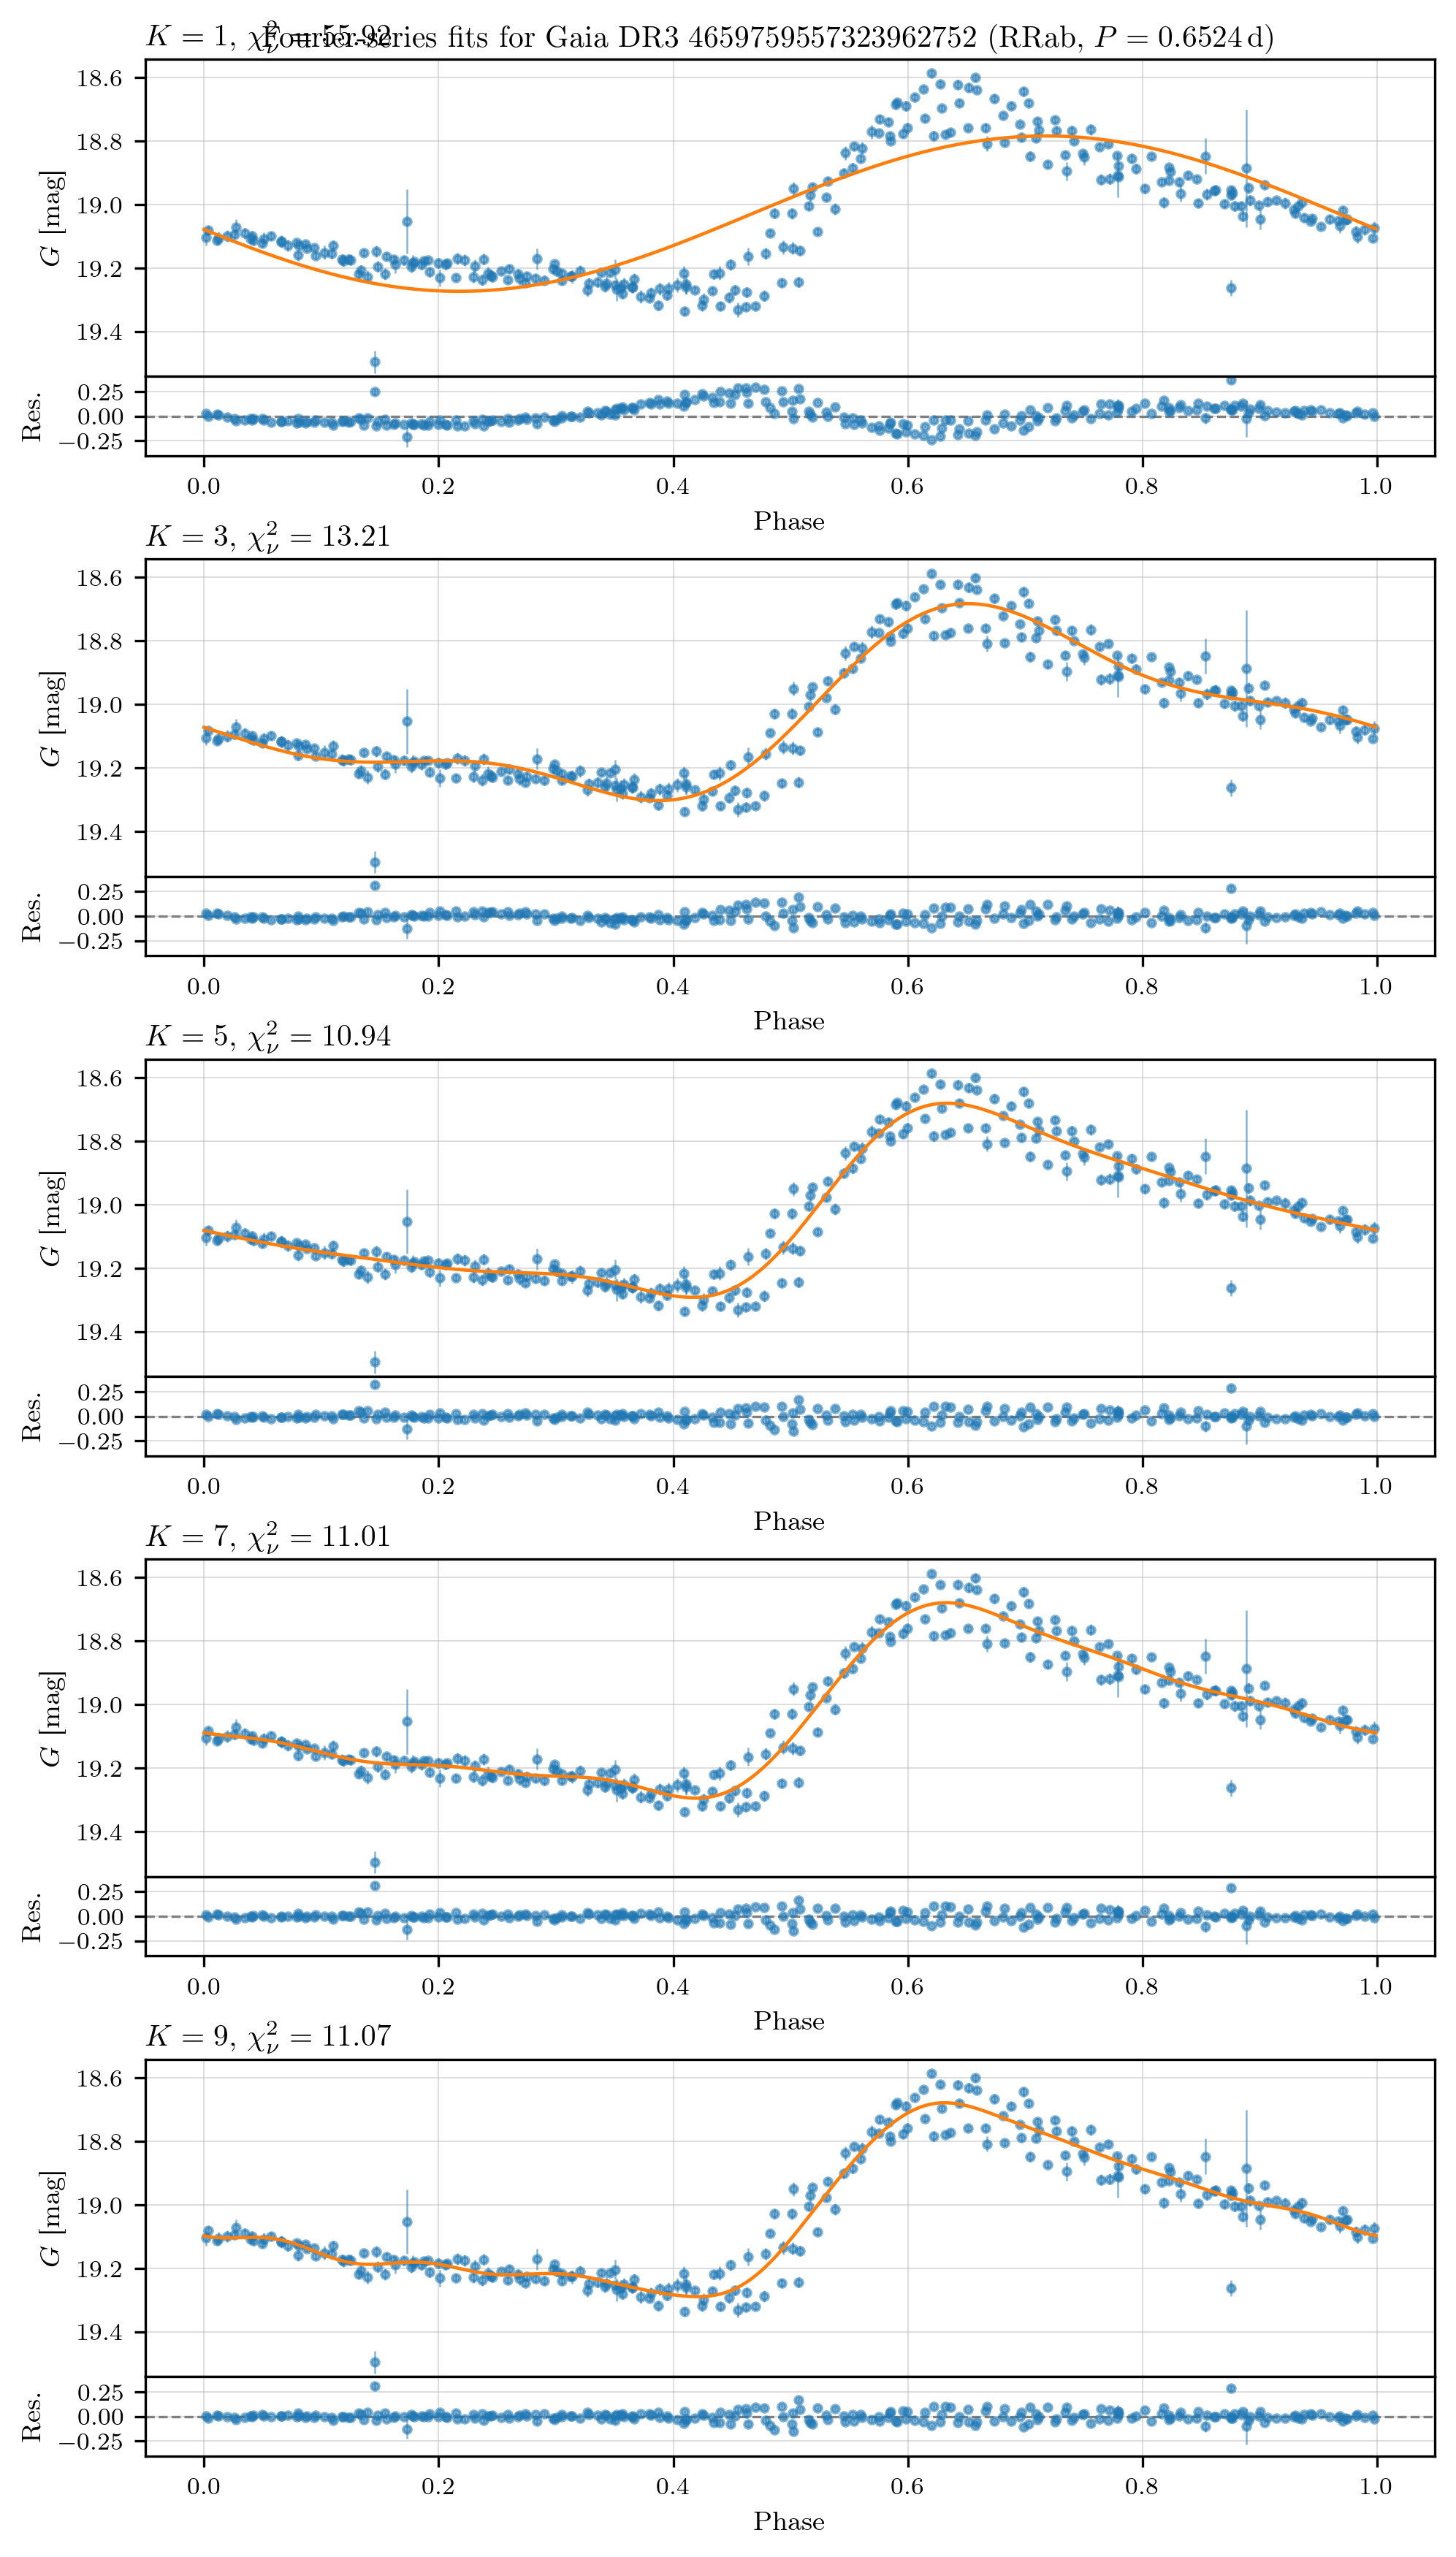

In [9]:
TARGET_ID = 4659759557323962752
K_values = [1, 3, 5, 7, 9]

lightcurve = lightcurve_data[np.asarray(lightcurve_data["source_id"], dtype=np.int64) == TARGET_ID]

row = lightcurve[0]
classification = str(row["best_classification"])
pf = float(np.ma.filled(row["pf"], np.nan))
p1_o = float(np.ma.filled(row["p1_o"], np.nan))
period = pf if classification == "RRab" else p1_o
if not np.isfinite(period):
    period = p1_o if np.isfinite(p1_o) else pf
if not np.isfinite(period):
    raise ValueError(f"Could not determine a finite Gaia period for source_id={TARGET_ID}.")

axes = plot_fourier_harmonic_fits(lightcurve, classification, period, K_values)
plt.show()

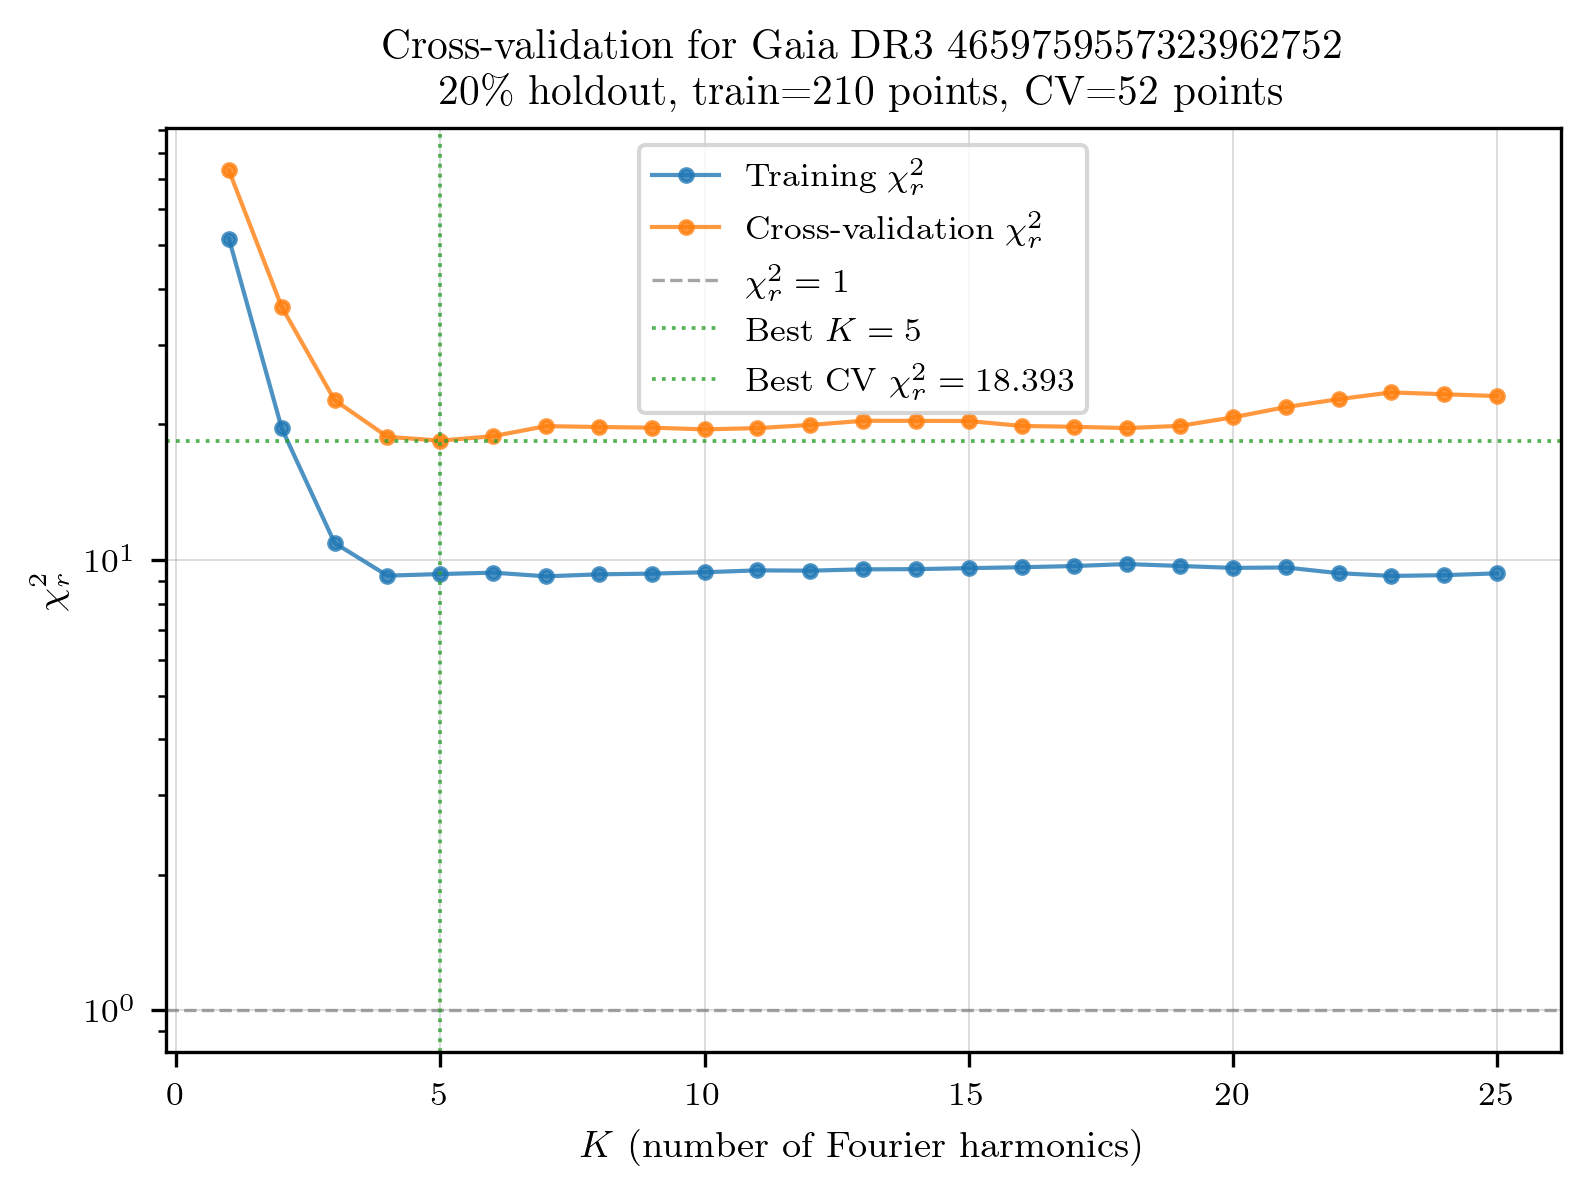

In [10]:
Ks, chi2r_train, chi2r_cv, best_K, train_idx, cv_idx = cross_validate_harmonics(lightcurve, period)
valid = np.isfinite(chi2r_train) & np.isfinite(chi2r_cv)
cv_best = float(chi2r_cv[Ks == best_K][0])

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.plot(Ks[valid], chi2r_train[valid], marker="o", ms=3, lw=1.0, alpha=0.8, label=r"Training $\chi_r^2$")
ax.plot(Ks[valid], chi2r_cv[valid], marker="o", ms=3, lw=1.0, alpha=0.8, label=r"Cross-validation $\chi_r^2$")
ax.axhline(1.0, color="C7", ls="--", lw=0.8, alpha=0.7, label=r"$\chi_r^2 = 1$")
ax.axvline(best_K, color="C2", ls=":", lw=0.9, alpha=0.8, label=rf"Best $K={best_K}$")
ax.axhline(cv_best, color="C2", ls=":", lw=0.9, alpha=0.8, label=rf"Best CV $\chi_r^2={cv_best:.3f}$")
ax.set_yscale("log")
ax.set_xlabel(r"$K$ (number of Fourier harmonics)")
ax.set_ylabel(r"$\chi_r^2$")
ax.set_title(
    f"Cross-validation for Gaia DR3 {TARGET_ID}\n"
    rf"20\% holdout, train={len(train_idx)} points, CV={len(cv_idx)} points"
)
ax.legend()
ax.grid(True)
plt.show()

In [11]:
from ugdatalab import fourier_fit
from ugdatalab.plotting import (
    _grid_1x2,
    TEXTWIDTH_IN,
    PRIMARY_COLOR,
    SECONDARY_COLOR,
    NEUTRAL_COLOR,
    LW_STANDARD,
)

clean_mask = (
    np.isfinite(np.asarray(lightcurve["g_transit_time"], dtype=float))
    & np.isfinite(np.asarray(lightcurve["g_transit_mag"], dtype=float))
    & np.isfinite(np.asarray(lightcurve["g_transit_mag_err"], dtype=float))
    & (np.asarray(lightcurve["g_transit_mag_err"], dtype=float) > 0)
)
clean_lightcurve = lightcurve[clean_mask]
train_lightcurve = clean_lightcurve[train_idx]
cv_lightcurve = clean_lightcurve[cv_idx]

train_epochs = np.asarray(train_lightcurve["g_transit_time"], dtype=float)
train_mags = np.asarray(train_lightcurve["g_transit_mag"], dtype=float)
train_errs = np.asarray(train_lightcurve["g_transit_mag_err"], dtype=float)
cv_epochs = np.asarray(cv_lightcurve["g_transit_time"], dtype=float)
cv_mags = np.asarray(cv_lightcurve["g_transit_mag"], dtype=float)
cv_errs = np.asarray(cv_lightcurve["g_transit_mag_err"], dtype=float)

valid_K_mask = np.isfinite(chi2r_train) & np.isfinite(chi2r_cv)
valid_Ks = np.asarray(Ks[valid_K_mask], dtype=int)
compare_Ks = [int(valid_Ks[0]), int(best_K)]
compare_labels = [rf"Low $K={compare_Ks[0]}$", rf"Best $K={compare_Ks[1]}$"]

fig, axes = _grid_1x2(figsize=(TEXTWIDTH_IN, 0.30 * TEXTWIDTH_IN), sharey=True, wspace=0.24)
bins = np.linspace(-5.0, 5.0, 31)
x_gauss = np.linspace(-5.0, 5.0, 400)
gaussian = np.exp(-0.5 * x_gauss**2) / np.sqrt(2.0 * np.pi)

for ax, K, label in zip(axes, compare_Ks, compare_labels):
    fit = fourier_fit(train_lightcurve, period, K)
    train_norm = (train_mags - fit.predict(train_epochs)) / train_errs
    cv_norm = (cv_mags - fit.predict(cv_epochs)) / cv_errs

    ax.hist(train_norm, bins=bins, histtype="step", density=True, color=PRIMARY_COLOR, lw=1.2, label="Training")
    ax.hist(cv_norm, bins=bins, histtype="step", density=True, color=SECONDARY_COLOR, lw=1.2, label="CV")
    ax.plot(x_gauss, gaussian, color=NEUTRAL_COLOR, ls="--", lw=LW_STANDARD, label=r"$\mathcal{N}(0,1)$")
    ax.axvline(0.0, color=NEUTRAL_COLOR, ls=":", lw=LW_STANDARD)
    ax.set_title(label)
    ax.set_xlabel(r"$(m - m_{\rm model})/\sigma$")
    ax.grid(True)

axes[0].set_ylabel("Density")
axes[0].legend(loc="best")
plt.show()

TypeError: _grid_1x2() got an unexpected keyword argument 'wspace'

In [ ]:
from ugdatalab import fourier_fit, phase_fold
from ugdatalab.plotting import (
    _grid_1x2,
    TEXTWIDTH_IN,
    PRIMARY_COLOR,
    SECONDARY_COLOR,
    QUATERNARY_COLOR,
    RRLYRAE_SCATTER_S,
    LW_STANDARD,
)

clean_mask = (
    np.isfinite(np.asarray(lightcurve["g_transit_time"], dtype=float))
    & np.isfinite(np.asarray(lightcurve["g_transit_mag"], dtype=float))
    & np.isfinite(np.asarray(lightcurve["g_transit_mag_err"], dtype=float))
    & (np.asarray(lightcurve["g_transit_mag_err"], dtype=float) > 0)
)
clean_lightcurve = lightcurve[clean_mask]
train_lightcurve = clean_lightcurve[train_idx]
cv_lightcurve = clean_lightcurve[cv_idx]

train_epochs = np.asarray(train_lightcurve["g_transit_time"], dtype=float)
train_mags = np.asarray(train_lightcurve["g_transit_mag"], dtype=float)
cv_epochs = np.asarray(cv_lightcurve["g_transit_time"], dtype=float)
cv_mags = np.asarray(cv_lightcurve["g_transit_mag"], dtype=float)

train_phase = phase_fold(train_epochs, period)
cv_phase = phase_fold(cv_epochs, period)
phase_grid = np.linspace(0.0, 1.0, 1000, endpoint=False)
epoch_grid = phase_grid * period

valid_K_mask = np.isfinite(chi2r_train) & np.isfinite(chi2r_cv)
valid_Ks = np.asarray(Ks[valid_K_mask], dtype=int)
high_K = int(valid_Ks[-1])
compare_Ks = [int(best_K), high_K]

fig, axes = _grid_1x2(figsize=(TEXTWIDTH_IN, 0.34 * TEXTWIDTH_IN), sharey=True, wspace=0.24)

all_mags = np.concatenate([train_mags, cv_mags])
pad = 0.05 * (np.max(all_mags) - np.min(all_mags))
y_limits = (np.max(all_mags) + pad, np.min(all_mags) - pad)

for ax, K in zip(axes, compare_Ks):
    fit = fourier_fit(train_lightcurve, period, K)
    model_mag = fit.predict(epoch_grid)

    ax.scatter(train_phase, train_mags, s=RRLYRAE_SCATTER_S, alpha=0.45, color=PRIMARY_COLOR, rasterized=True, label="Training")
    ax.scatter(cv_phase, cv_mags, s=RRLYRAE_SCATTER_S, alpha=0.9, color=QUATERNARY_COLOR, rasterized=True, label="CV")
    ax.plot(phase_grid, model_mag, color=SECONDARY_COLOR, lw=LW_STANDARD, label=rf"Model ($K={K}$)")
    ax.set_ylim(y_limits)
    ax.invert_yaxis()
    ax.set_xlabel("Phase")
    ax.set_title(rf"Phase-folded fit with $K={K}$")
    ax.grid(True)

axes[0].set_ylabel(r"$G$ [mag]")
axes[0].legend(loc="best")
plt.show()

## Cross-Validation Diagnostic Discussion

The cross-validation curve identifies the harmonic order that best balances flexibility against predictive performance, but the two additional diagnostic plots make the underfitting-to-overfitting transition easier to interpret physically.

The **low-**$K$ normalized-residual histogram shows what happens when the Fourier model is too simple. In that regime, both the training and cross-validation residuals are typically broader than the reference $\mathcal{N}(0,1)$ curve, which indicates that the model is leaving real light-curve structure in the residuals rather than capturing it.

At **best** $K$, the training and cross-validation histograms should come closer together and move closer to the $\mathcal{N}(0,1)$ reference. That is the behavior expected for a model that is flexible enough to describe the signal without yet fitting the noise.

The **high-**$K$ phase-folded comparison then illustrates the opposite failure mode. Once too many harmonics are added, the model curve becomes more wiggly and starts following the training points more aggressively, while the held-out cross-validation points are not matched correspondingly better. That is the visual signature of overfitting: extra structure is being used to chase noise in the training data rather than improving out-of-sample prediction.

Taken together, these plots provide a coherent interpretation of the chosen harmonic order: low $K$ underfits, high $K$ overfits, and the cross-validation minimum identifies the intermediate value that best captures the astrophysical light-curve shape.

In [ ]:
from ugdatalab import fourier_fit, predict_future_magnitude
from ugdatalab.plotting import (
    TEXTWIDTH_IN,
    PRIMARY_COLOR,
    SECONDARY_COLOR,
    NEUTRAL_COLOR,
    RRLYRAE_MARKER_MS,
    RRLYRAE_POINT_ALPHA,
    LW_FINE,
    LW_STANDARD,
)

fit = fourier_fit(lightcurve, period, best_K)
epoch_pred, mag_pred = predict_future_magnitude(fit)

epoch_last = float(np.max(fit.epochs))
window_days = 5.0
future_days = 12.0
epoch_window_start = epoch_last - window_days
epoch_window_end = epoch_last + future_days
epoch_grid = np.linspace(epoch_window_start, epoch_window_end, 2000)
mag_grid = fit.predict(epoch_grid)

observed_mask = fit.epochs >= epoch_window_start
model_observed = epoch_grid <= epoch_last

time_unit = getattr(lightcurve["g_transit_time"], "unit", None)
time_label = f"Time [{time_unit}]" if time_unit is not None else "Time"

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 0.5 * TEXTWIDTH_IN), dpi=300)
ax.errorbar(
    fit.epochs[observed_mask],
    fit.mags[observed_mask],
    yerr=fit.mag_errs[observed_mask],
    fmt="o",
    ms=RRLYRAE_MARKER_MS,
    elinewidth=LW_FINE,
    color=PRIMARY_COLOR,
    alpha=RRLYRAE_POINT_ALPHA,
    label="Gaia data",
)
ax.plot(
    epoch_grid[model_observed],
    mag_grid[model_observed],
    color=SECONDARY_COLOR,
    lw=LW_STANDARD,
    label=rf"Fourier fit ($K={best_K}$)",
)
ax.plot(
    epoch_grid[~model_observed],
    mag_grid[~model_observed],
    color=SECONDARY_COLOR,
    lw=LW_STANDARD,
    ls="--",
    label="12-day extrapolation",
)
ax.axvline(epoch_last, color=NEUTRAL_COLOR, ls=":", lw=LW_STANDARD, alpha=0.8)
ax.plot(
    epoch_pred,
    mag_pred,
    marker="*",
    ms=8,
    color="k",
    lw=0,
    label=rf"10-day prediction: $G={mag_pred:.3f}$",
)
ax.invert_yaxis()
ax.set_xlim(epoch_window_start, epoch_window_end)
ax.set_xlabel(time_label)
ax.set_ylabel(r"$G$ [mag]")
ax.set_title(
    rf"Fourier extrapolation for Gaia DR3 {TARGET_ID} ($K={best_K}$, $P={period:.4f}\,\mathrm{{d}}$)"
)
ax.legend(loc="upper left")
ax.grid(True)
plt.show()

In [ ]:
from ugdatalab import fourier_mean_magnitude
from ugdatalab.plotting import (
    TEXTWIDTH_IN,
    PRIMARY_COLOR,
    SECONDARY_COLOR,
    NEUTRAL_COLOR,
    RRLYRAE_SCATTER_S,
    RRLYRAE_POINT_ALPHA,
    LW_STANDARD,
)

source_ids = np.asarray(summary["source_id"], dtype=np.int64)
periods = np.asarray(summary["best_period"], dtype=float)
simple_mean_g = np.asarray(summary["mean_apparent_g"], dtype=float)
gaia_int_average_g = np.asarray(summary_rows["int_average_g"], dtype=float)

fourier_mean_g = np.full(len(source_ids), np.nan, dtype=float)
for i, source_id in enumerate(source_ids):
    star = lightcurve_data[np.asarray(lightcurve_data["source_id"], dtype=np.int64) == source_id]
    fit = fourier_fit(star, periods[i], best_K)
    fourier_mean_g[i] = fourier_mean_magnitude(fit)

summary["fourier_mean_apparent_g"] = fourier_mean_g
summary["gaia_int_average_g"] = gaia_int_average_g

simple_valid = np.isfinite(simple_mean_g) & np.isfinite(gaia_int_average_g)
fourier_valid = np.isfinite(fourier_mean_g) & np.isfinite(gaia_int_average_g)
all_values = np.concatenate([
    simple_mean_g[simple_valid],
    fourier_mean_g[fourier_valid],
    gaia_int_average_g[simple_valid],
    gaia_int_average_g[fourier_valid],
])
pad = 0.05 * (np.max(all_values) - np.min(all_values))
lims = np.array([np.min(all_values) - pad, np.max(all_values) + pad])

resid_simple = simple_mean_g - gaia_int_average_g
resid_fourier = fourier_mean_g - gaia_int_average_g
resid_max = 1.1 * np.nanmax(np.abs(np.concatenate([resid_simple[simple_valid], resid_fourier[fourier_valid]])))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(TEXTWIDTH_IN, 0.68 * TEXTWIDTH_IN),
    dpi=300,
    sharex="col",
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.0, "wspace": 0.28},
)
(ax_simple, ax_fourier), (ax_simple_resid, ax_fourier_resid) = axes

ax_simple.scatter(
    gaia_int_average_g[simple_valid],
    simple_mean_g[simple_valid],
    s=RRLYRAE_SCATTER_S,
    alpha=RRLYRAE_POINT_ALPHA,
    color=PRIMARY_COLOR,
    rasterized=True,
)
ax_simple.plot(lims, lims, color=NEUTRAL_COLOR, ls="--", lw=LW_STANDARD)
ax_simple.set_xlim(lims)
ax_simple.set_ylim(lims)
ax_simple.set_ylabel(r"Part (3) $\langle G \rangle$ [mag]")
ax_simple.set_title("Direct flux-space mean vs Gaia catalog")
ax_simple.grid(True)

ax_simple_resid.scatter(
    gaia_int_average_g[simple_valid],
    resid_simple[simple_valid],
    s=RRLYRAE_SCATTER_S,
    alpha=RRLYRAE_POINT_ALPHA,
    color=PRIMARY_COLOR,
    rasterized=True,
)
ax_simple_resid.axhline(0.0, color=NEUTRAL_COLOR, ls="--", lw=LW_STANDARD)
ax_simple_resid.set_xlabel(r"Gaia $\mathtt{int\_average\_g}$ [mag]")
ax_simple_resid.set_ylabel("Res.")
ax_simple_resid.set_ylim(-resid_max, resid_max)
ax_simple_resid.grid(True)

ax_fourier.scatter(
    gaia_int_average_g[fourier_valid],
    fourier_mean_g[fourier_valid],
    s=RRLYRAE_SCATTER_S,
    alpha=RRLYRAE_POINT_ALPHA,
    color=SECONDARY_COLOR,
    rasterized=True,
)
ax_fourier.plot(lims, lims, color=NEUTRAL_COLOR, ls="--", lw=LW_STANDARD)
ax_fourier.set_xlim(lims)
ax_fourier.set_ylim(lims)
ax_fourier.set_ylabel(r"Fourier $\langle G \rangle$ [mag]")
ax_fourier.set_title(rf"Fourier mean ($K={best_K}$) vs Gaia catalog")
ax_fourier.grid(True)

ax_fourier_resid.scatter(
    gaia_int_average_g[fourier_valid],
    resid_fourier[fourier_valid],
    s=RRLYRAE_SCATTER_S,
    alpha=RRLYRAE_POINT_ALPHA,
    color=SECONDARY_COLOR,
    rasterized=True,
)
ax_fourier_resid.axhline(0.0, color=NEUTRAL_COLOR, ls="--", lw=LW_STANDARD)
ax_fourier_resid.set_xlabel(r"Gaia $\mathtt{int\_average\_g}$ [mag]")
ax_fourier_resid.set_ylabel("Res.")
ax_fourier_resid.set_ylim(-resid_max, resid_max)
ax_fourier_resid.grid(True)

plt.show()

rms_simple = float(np.sqrt(np.mean(resid_simple[simple_valid] ** 2)))
rms_fourier = float(np.sqrt(np.mean(resid_fourier[fourier_valid] ** 2)))
mad_simple = float(np.median(np.abs(resid_simple[simple_valid])))
mad_fourier = float(np.median(np.abs(resid_fourier[fourier_valid])))

print(f"Part (3) direct flux-space mean: RMS residual = {rms_simple:.4f} mag, median |residual| = {mad_simple:.4f} mag")
print(f"Fourier mean (K={best_K}): RMS residual = {rms_fourier:.4f} mag, median |residual| = {mad_fourier:.4f} mag")

## Mean-Magnitude Comparison Discussion

The Gaia catalog quantity `int_average_g` is an **intensity-averaged** magnitude, so the most like-for-like comparison is the Fourier-based estimate that also averages the flux over a full pulsation cycle before converting back to magnitudes. By contrast, the direct estimate from part (3) uses only the observed epochs. Even though that average is correctly performed in flux space, it can still be biased when the sampling is uneven in phase and some parts of the light curve are over-represented.

After running the previous cell, compare the two upper panels to the 1:1 line and compare the two residual panels to the zero line. If the Fourier-based points lie closer to the 1:1 relation and its residuals show a smaller scatter than the part (3) estimate, that indicates the Fourier model is correcting for phase-sampling bias and producing a better estimate of the cycle-averaged mean magnitude.

The printed RMS and median absolute residuals provide a compact quantitative check of the same conclusion. Any stars that still remain as outliers are likely tracing limitations of the adopted single-period Fourier model, imperfect period estimates, insufficient harmonic complexity, or intrinsically more complicated light curves such as multi-mode pulsators.